## Topic 9  Add Dynamics

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
def plot_add_dynamics(G0,Gd,fig_caption,file_name,dim = None):

    if dim is None:
        dim = 5
        
    for kk,Gpert in enumerate(Gd):
        print(file_name+str(kk+1)+".pdf")        
        G1 = G0*Gpert
        klist0, break_info0 = cm.Root_Locus_gains(G0,verbose=True)
        klist1, break_info1 = cm.Root_Locus_gains(G1,verbose=True)
        
        fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
        rl = ct.rlocus(G0, gains=klist0, color='b', ax=ax[0])
        ax[0].set_xlim([-dim, dim]);ax[0].set_ylim([-dim, dim])
        bm.nicegrid(ax[0],5)
        cm.new_pzmap(G0, ax=ax[0])
        
        ax[1].set_xlim([-dim, dim]);ax[1].set_ylim([-dim, dim])
        bm.nicegrid(ax[1],5)
        cm.caption(fig_caption[kk],fig)
        cm.new_pzmap(G1, ax=ax[1])
        for ll in range(2):
            ax[ll].set_xlabel('Real')
            ax[ll].set_ylabel('Imaginary')

        plt.savefig(file_name+str(kk+1)+".pdf", dpi=300)
        plt.show()
        
        klist0, break_info0 = cm.Root_Locus_gains(G0,verbose=True)
        klist1, break_info1 = cm.Root_Locus_gains(G1,verbose=True)

        fig, ax = plt.subplots(1,2,figsize=(8, 4),dpi=150,constrained_layout = True)
        rl = ct.rlocus(G0, gains=klist0, color='b', ax=ax[0])
        ax[0].set_xlim([-dim, dim]);ax[0].set_ylim([-dim, dim])
        bm.nicegrid(ax[0],5)
        cm.new_pzmap(G0, ax=ax[0])
        
        rl = ct.rlocus(G1, gains=klist1, color='b', ax=ax[1])
        ax[1].set_xlim([-dim, dim]);ax[1].set_ylim([-dim, dim])
        bm.nicegrid(ax[1],5)
        cm.new_pzmap(G1, ax=ax[1])
        cm.caption(fig_caption[kk],fig)
        
        for ll in range(2):
            ax[ll].set_xlabel('Real')
            ax[ll].set_ylabel('Imaginary')

        cm.add_break_info(ax[0], break_info0, dim=dim)
        cm.add_break_info(ax[1], break_info1, dim=dim)

        plt.savefig(file_name+str(kk+1)+"_sol.pdf", dpi=300)
        plt.show()

./figs/L9_1.pdf


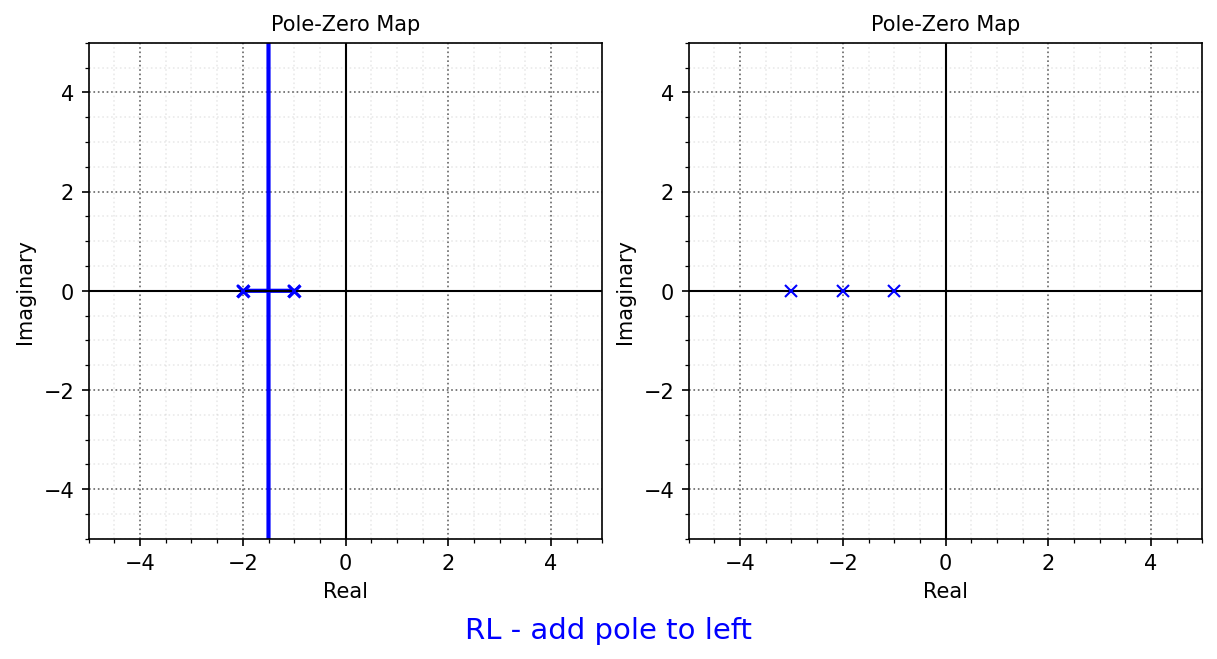

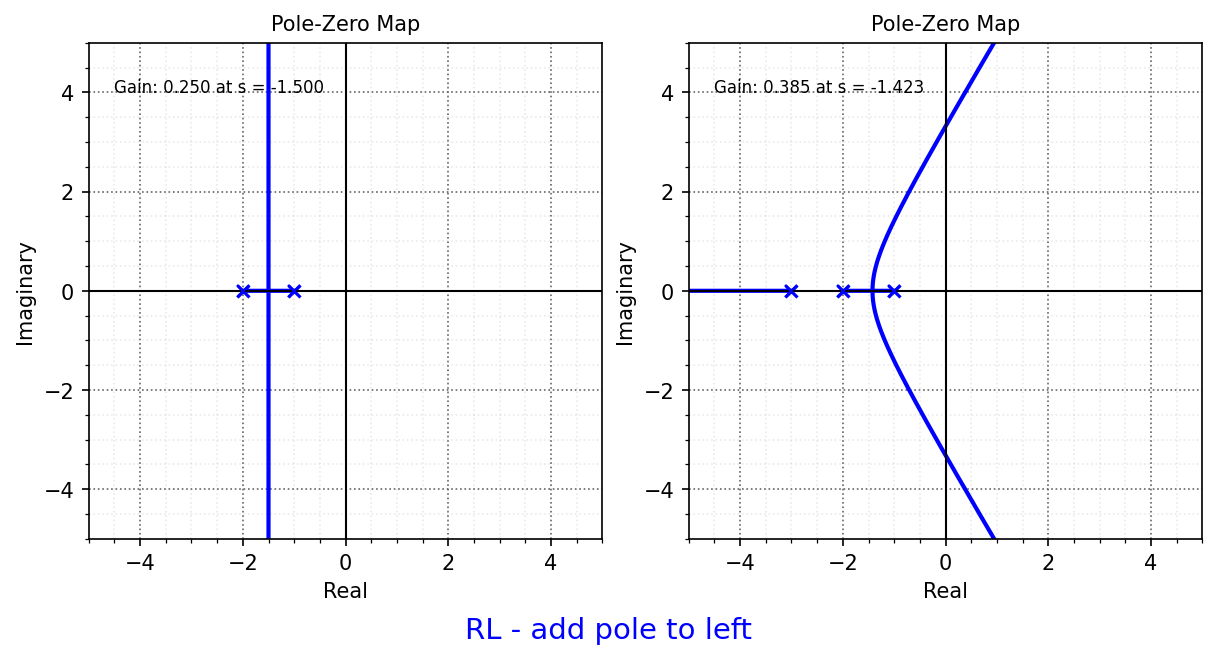

./figs/L9_2.pdf


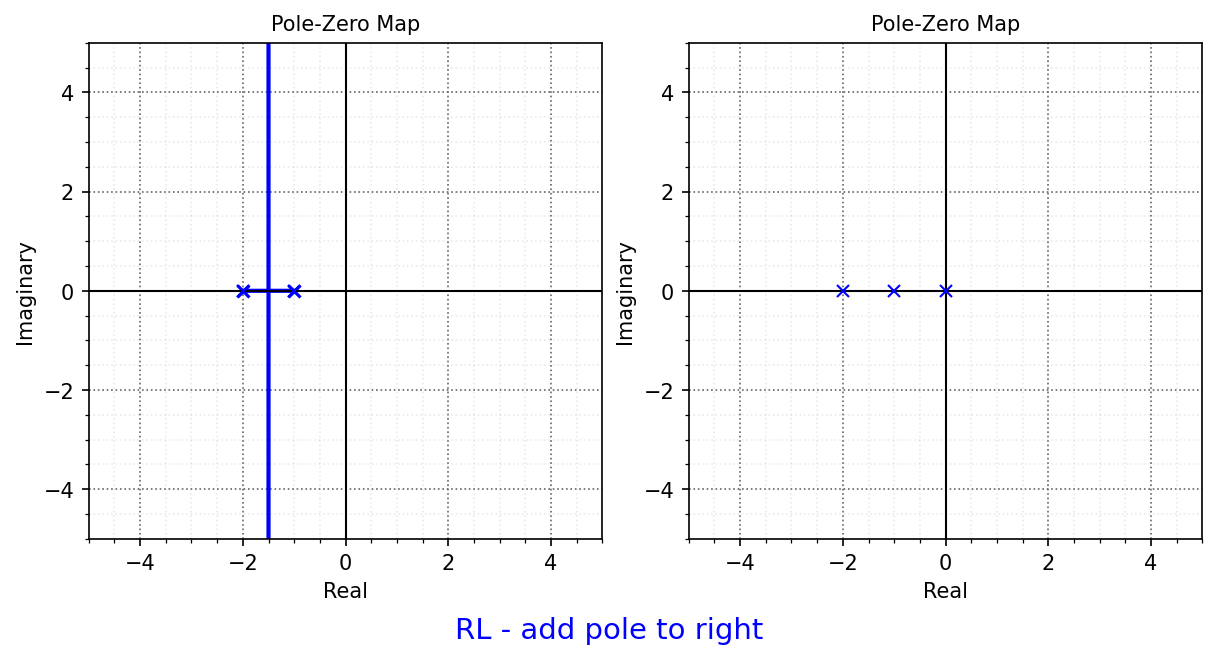

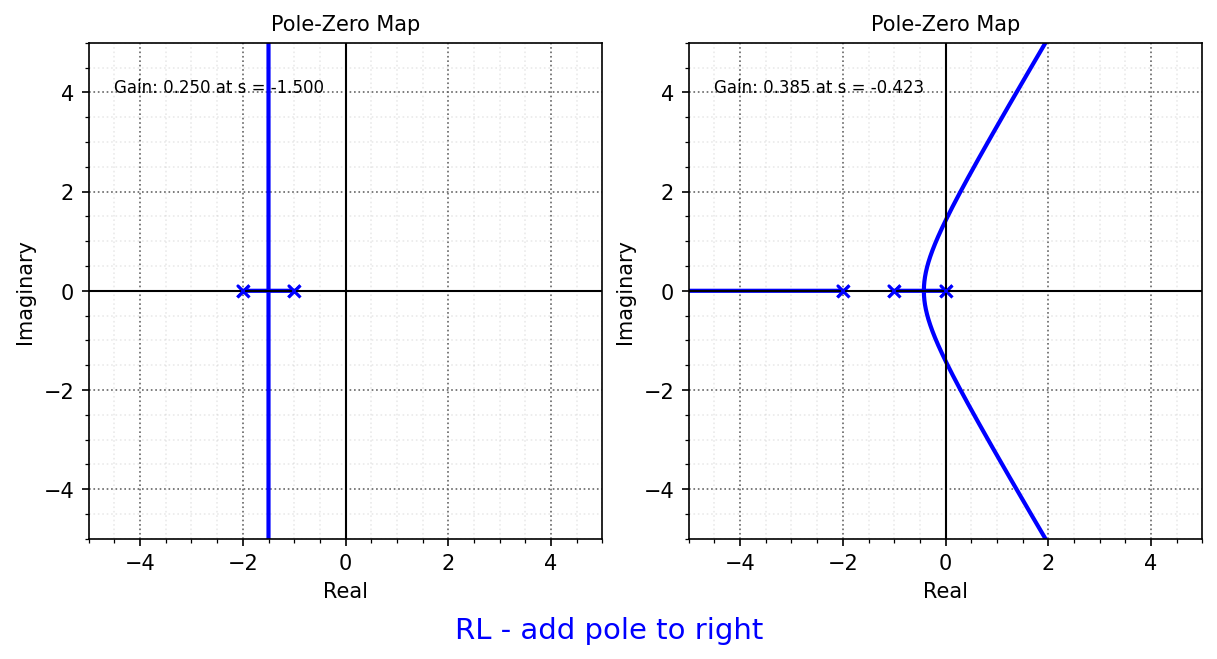

./figs/L9_3.pdf


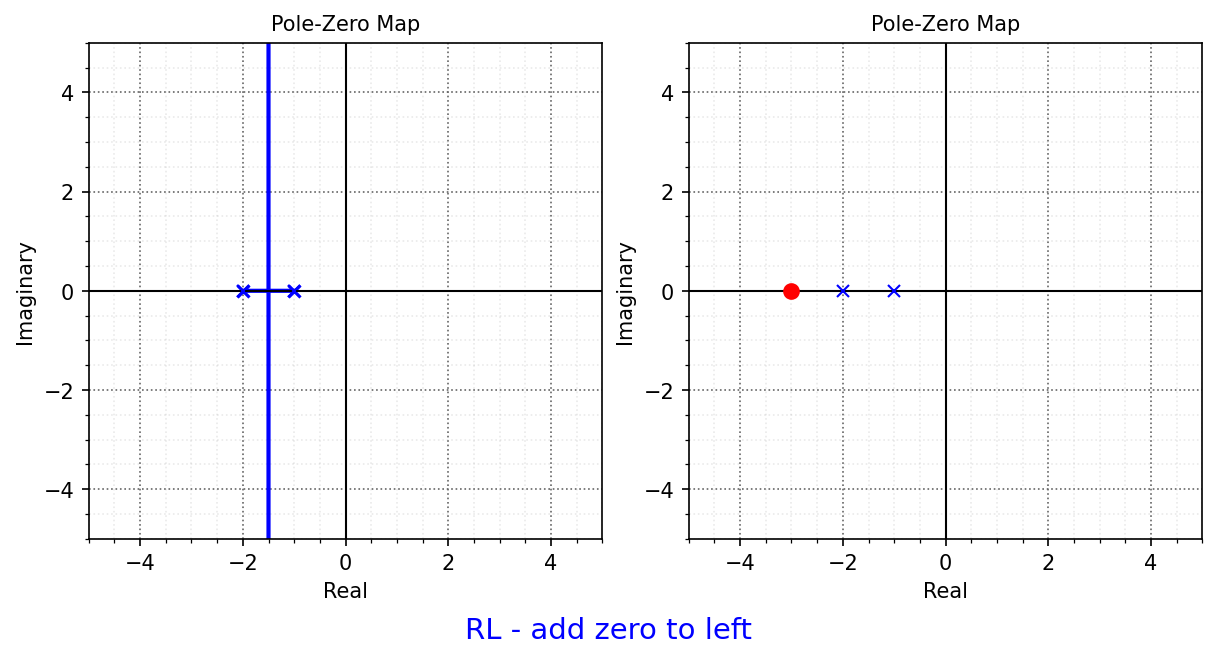

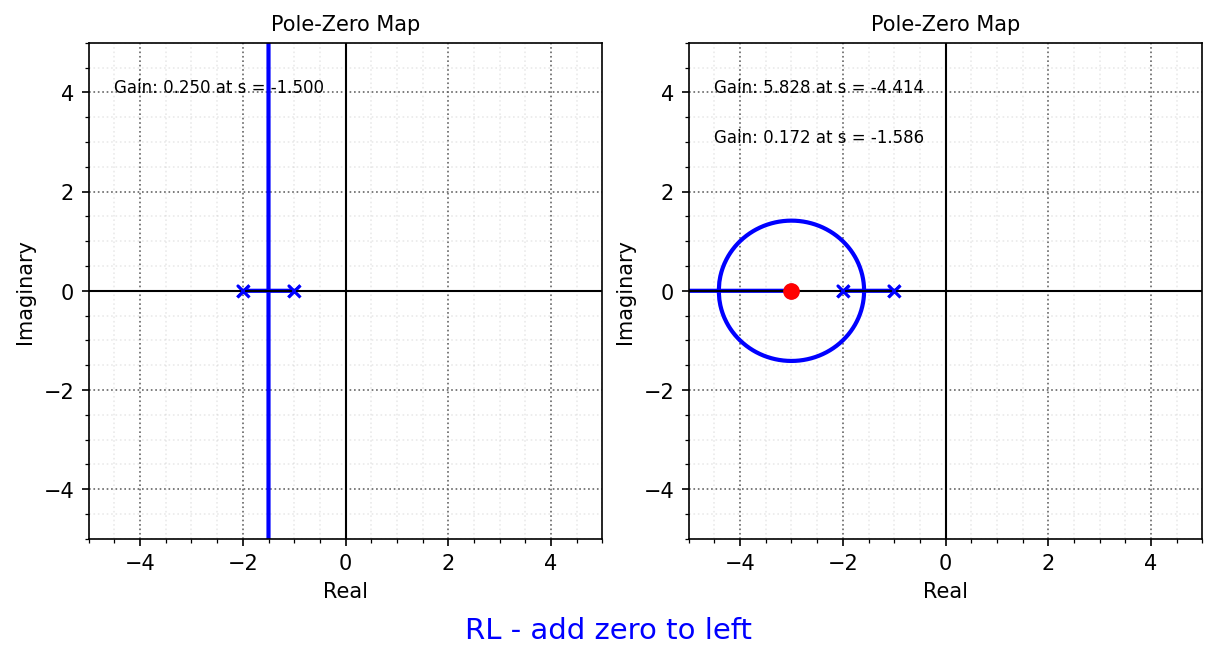

./figs/L9_4.pdf


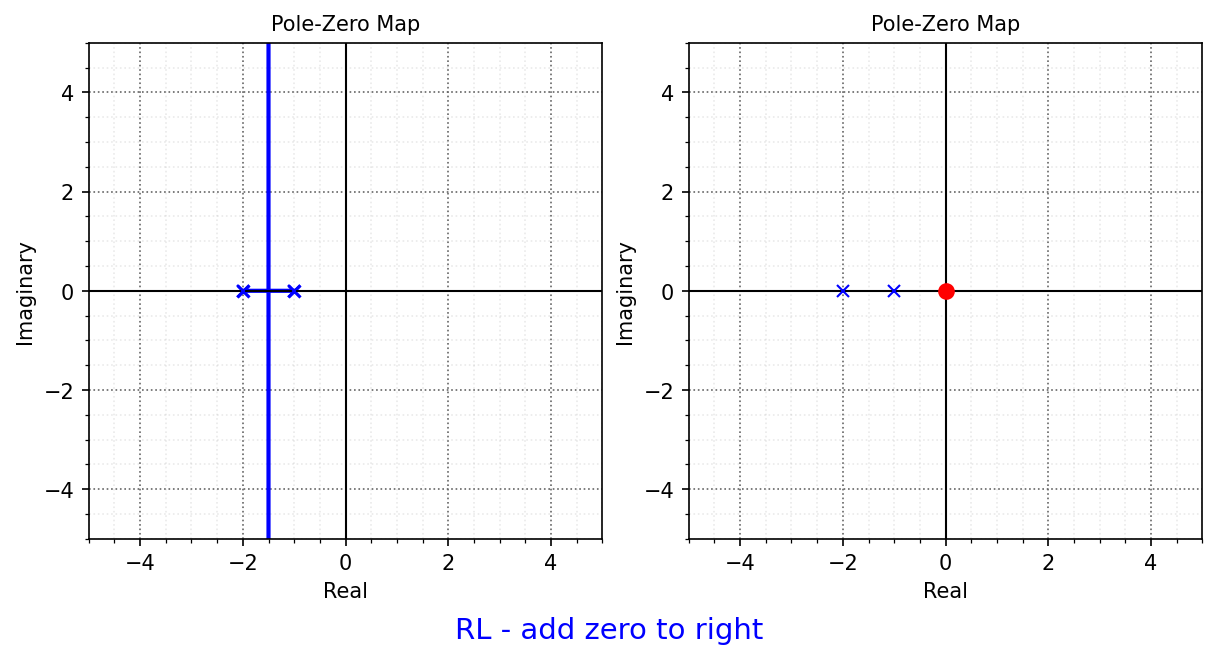

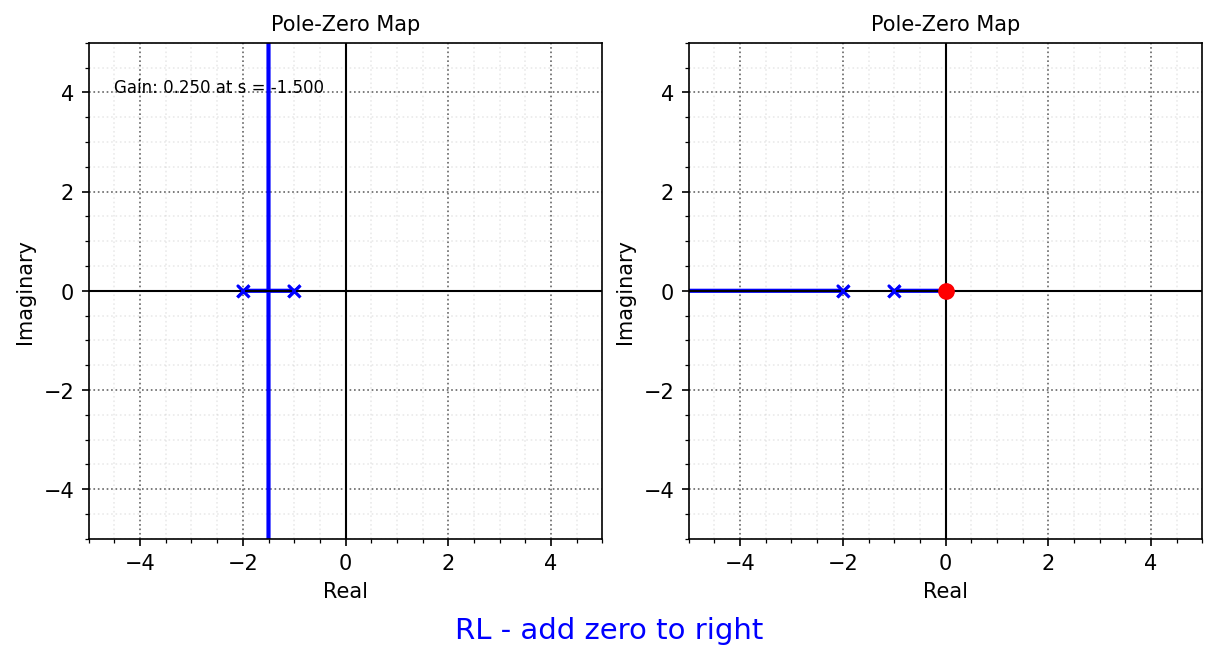

./figs/L9_5.pdf


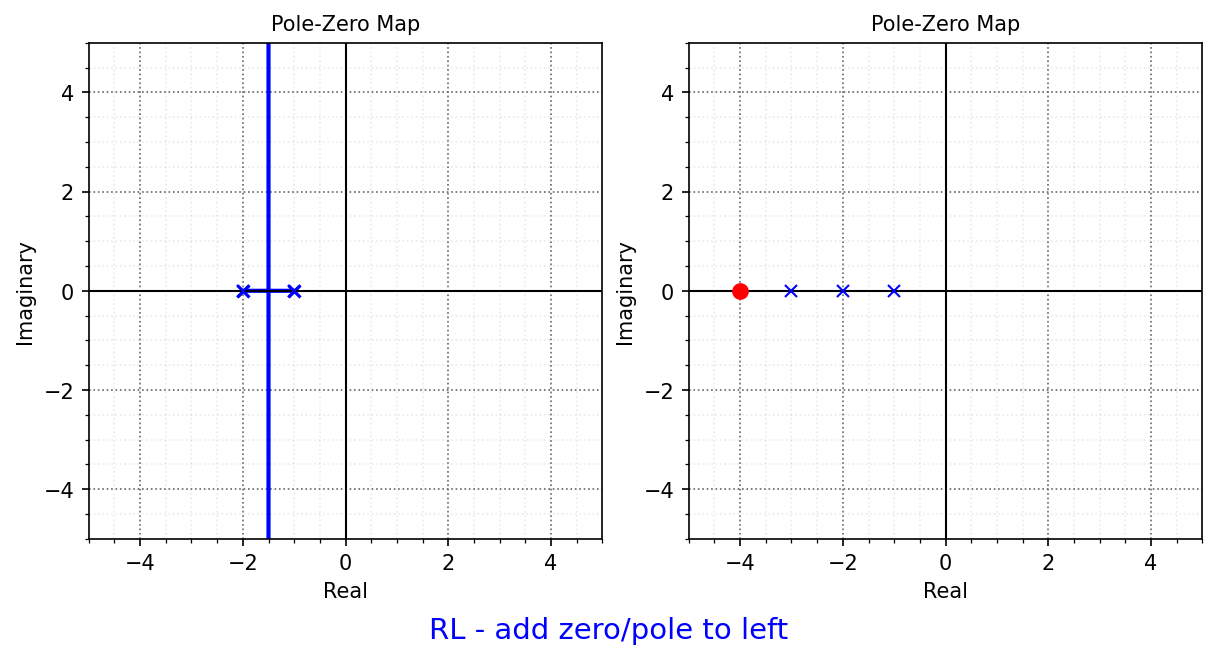

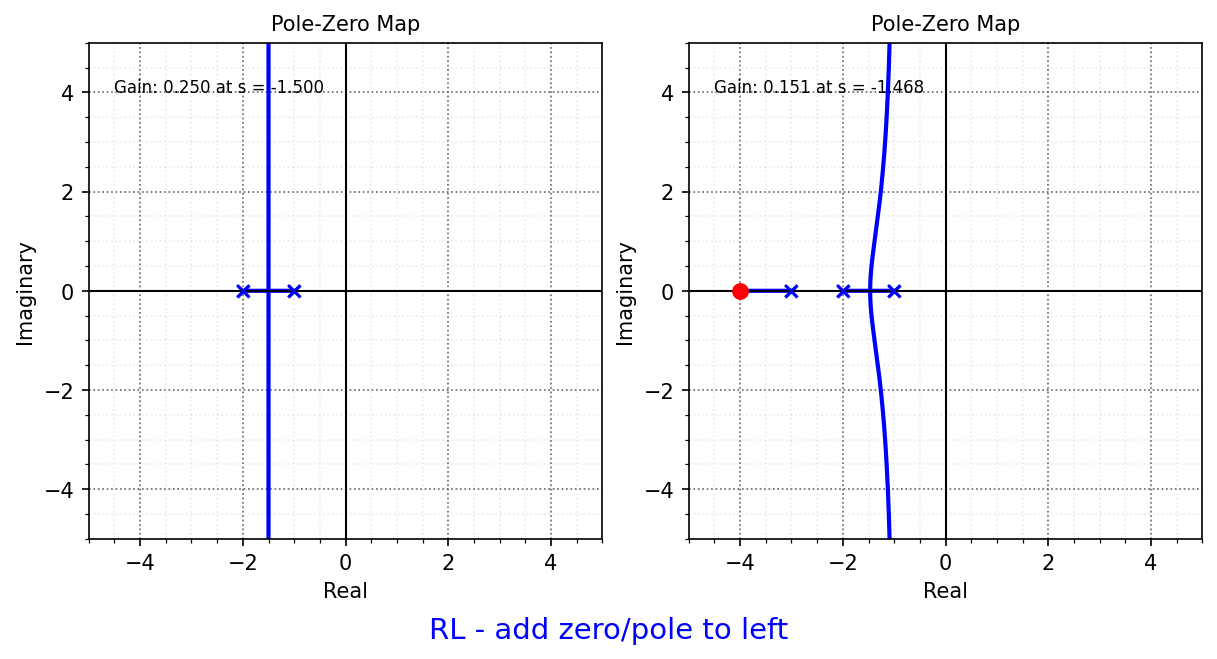

./figs/L9_6.pdf


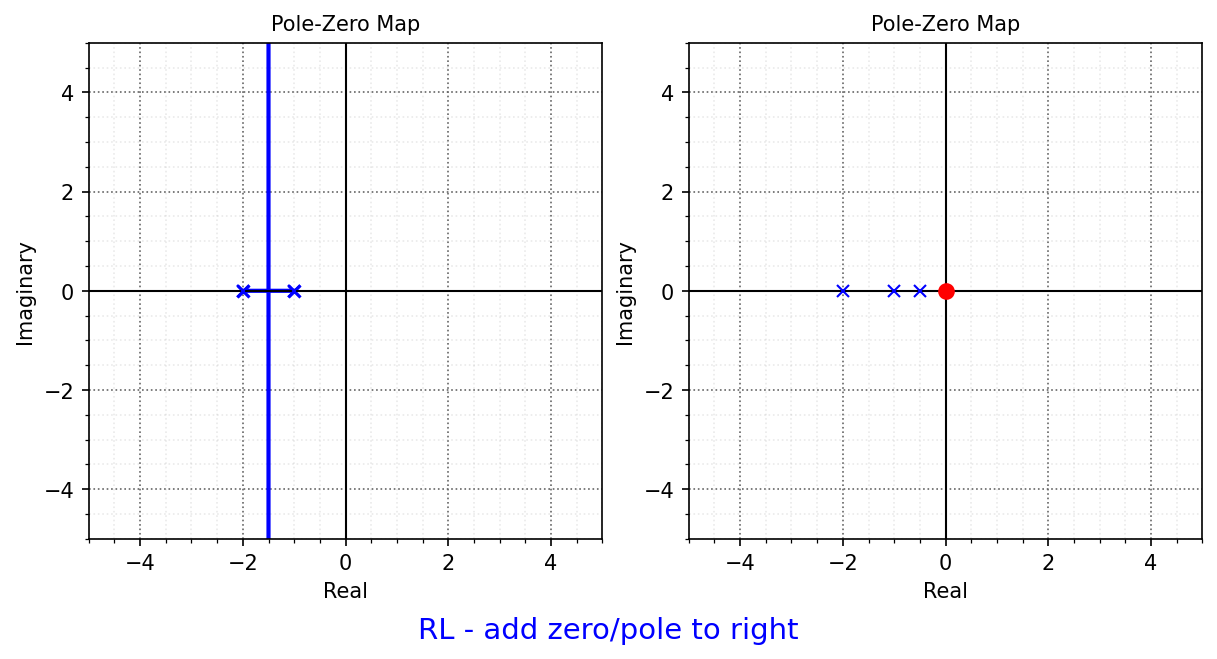

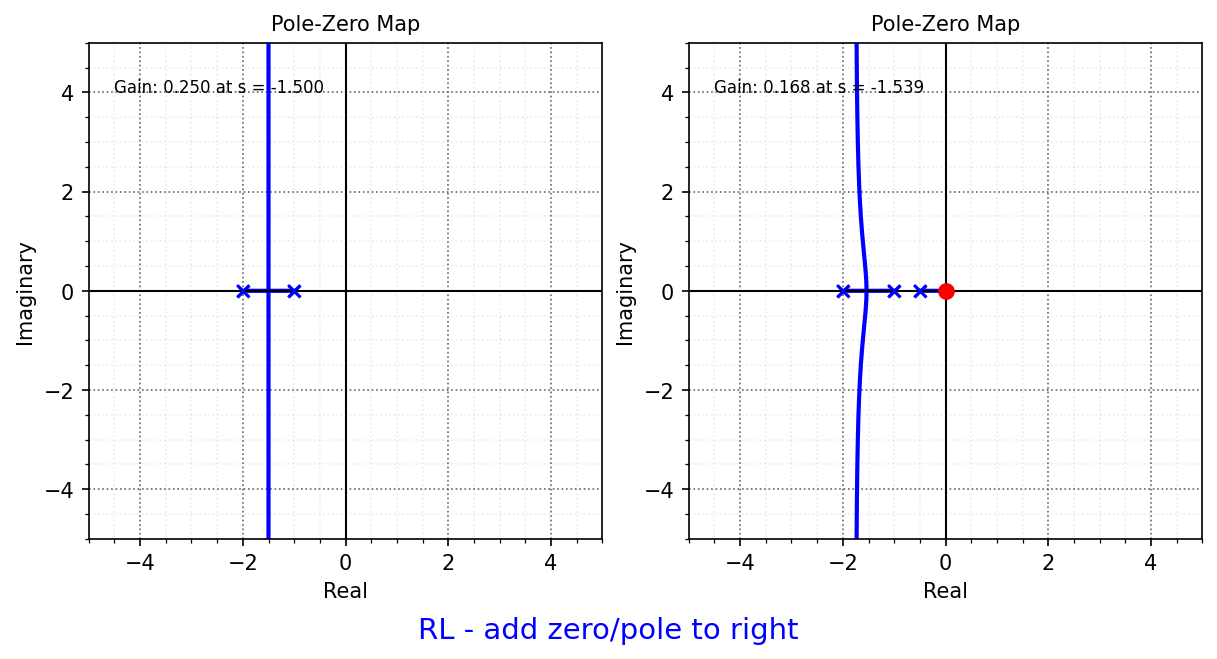

In [5]:
# add dynamics
G0 = ct.tf(np.convolve((0, 1),(0, 1)), np.convolve((1,1),(1, 2)))

Gd = [
    ct.tf((0, 1), (1, 3)),
    ct.tf((0, 1), (1, 0)),
    ct.tf((1, 3), (0, 1)),
    ct.tf((1, 0), (0, 1)),
    ct.tf((1, 4), (1, 3)),
    ct.tf((1, 0), (1, 0.5))]
fig_caption = [
    "RL - add pole to left", 
    "RL - add pole to right",
    "RL - add zero to left",
    "RL - add zero to right",
    "RL - add zero/pole to left",
    "RL - add zero/pole to right"
]
file_name = "./figs/L9_"
plot_add_dynamics(G0,Gd,fig_caption,file_name)

## Add More Dynamics

./figs/L9_2_1.pdf


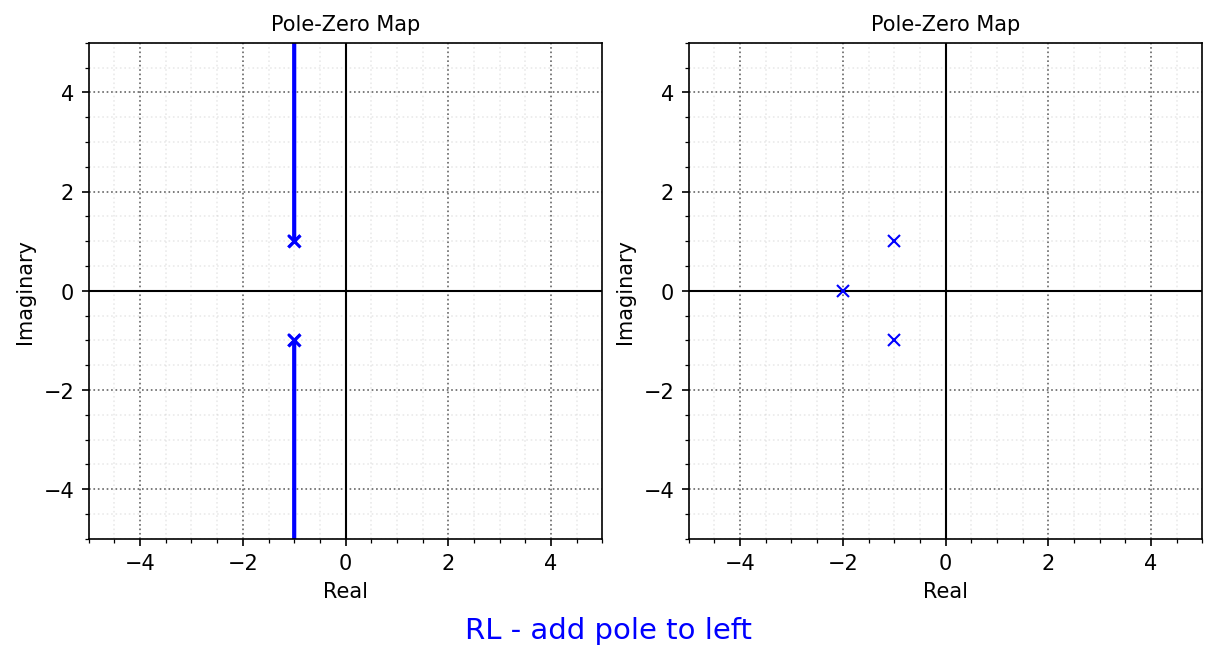

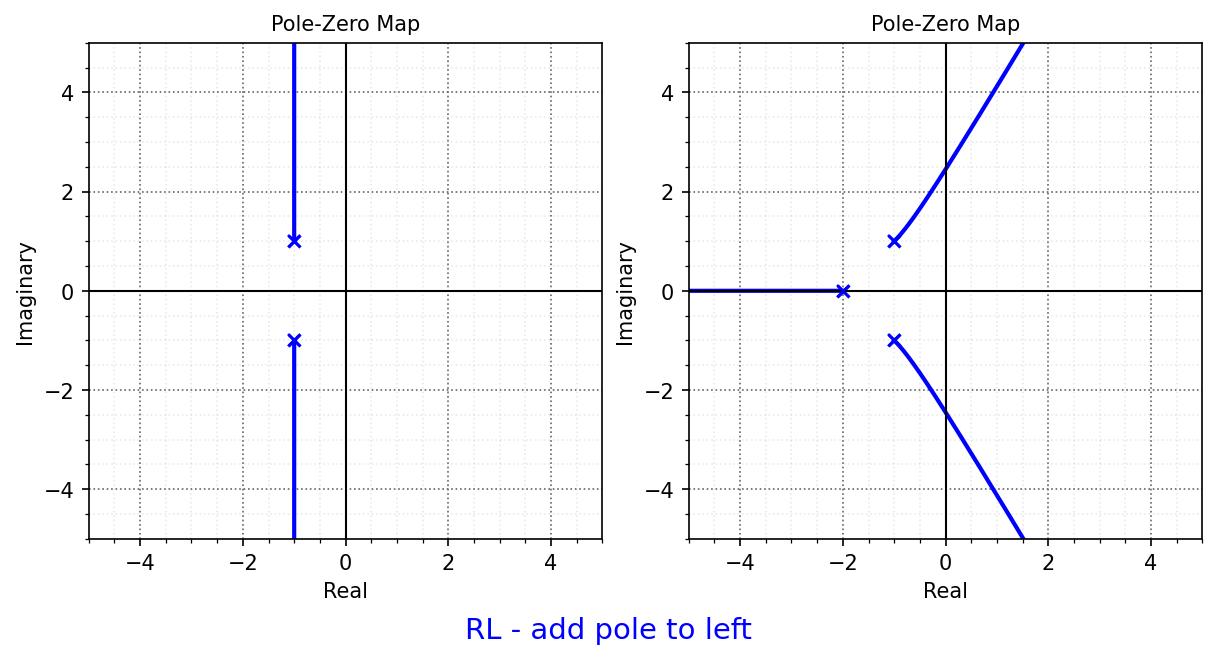

./figs/L9_2_2.pdf


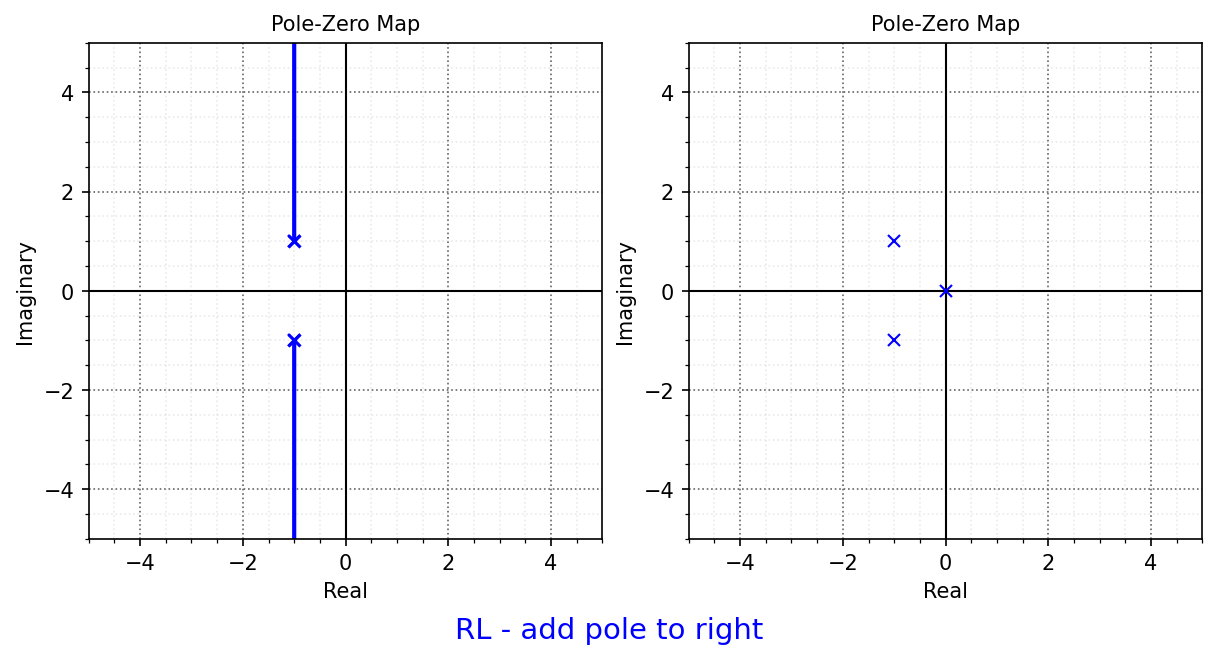

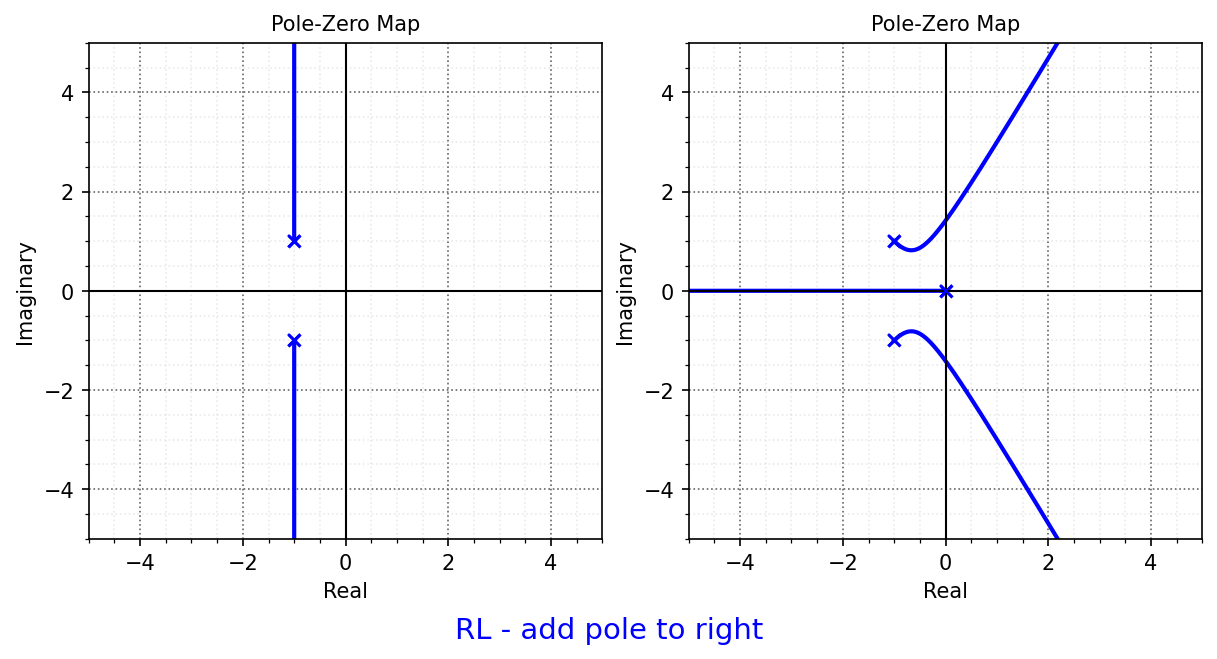

./figs/L9_2_3.pdf


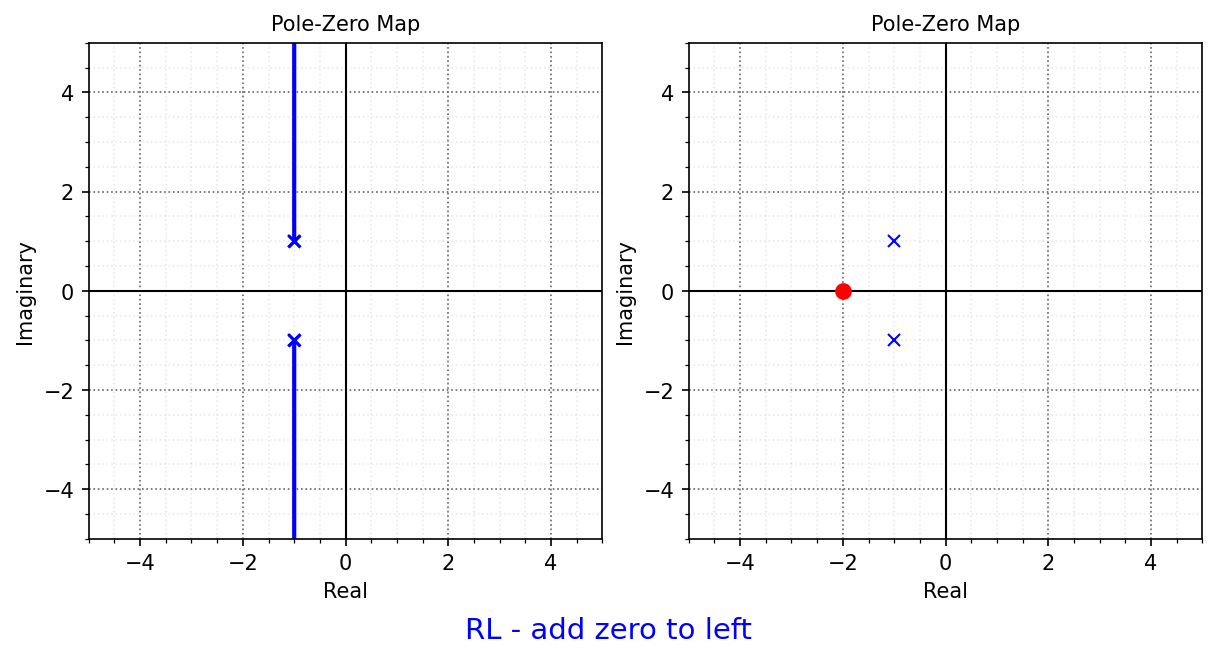

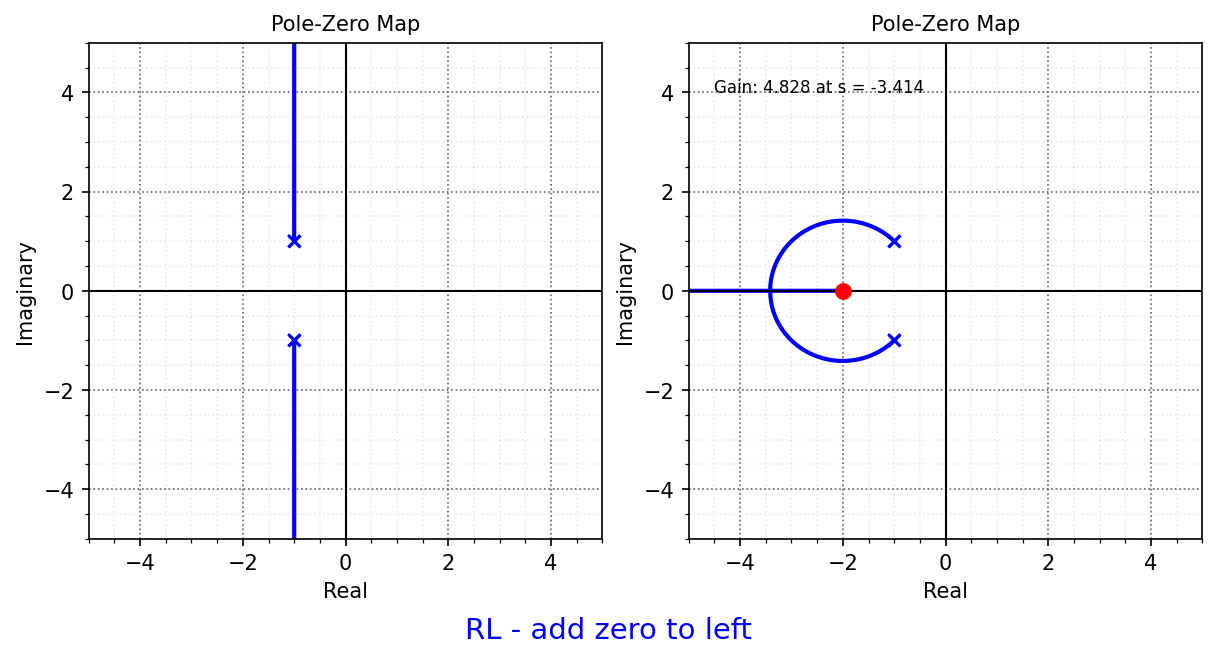

./figs/L9_2_4.pdf


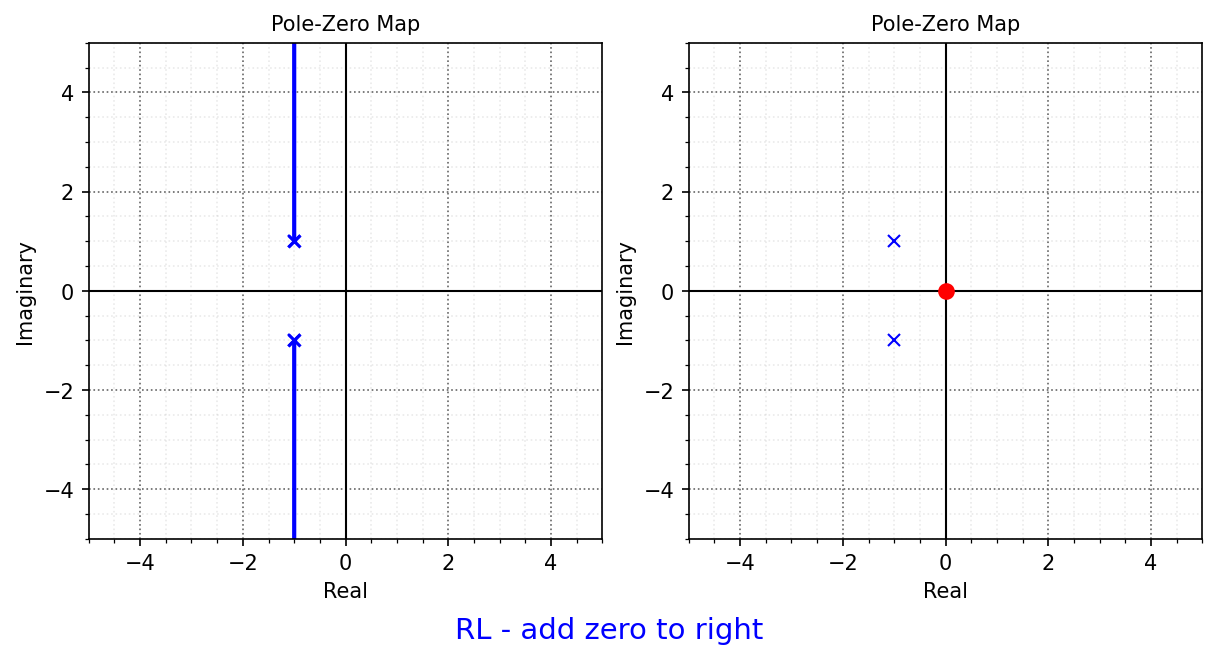

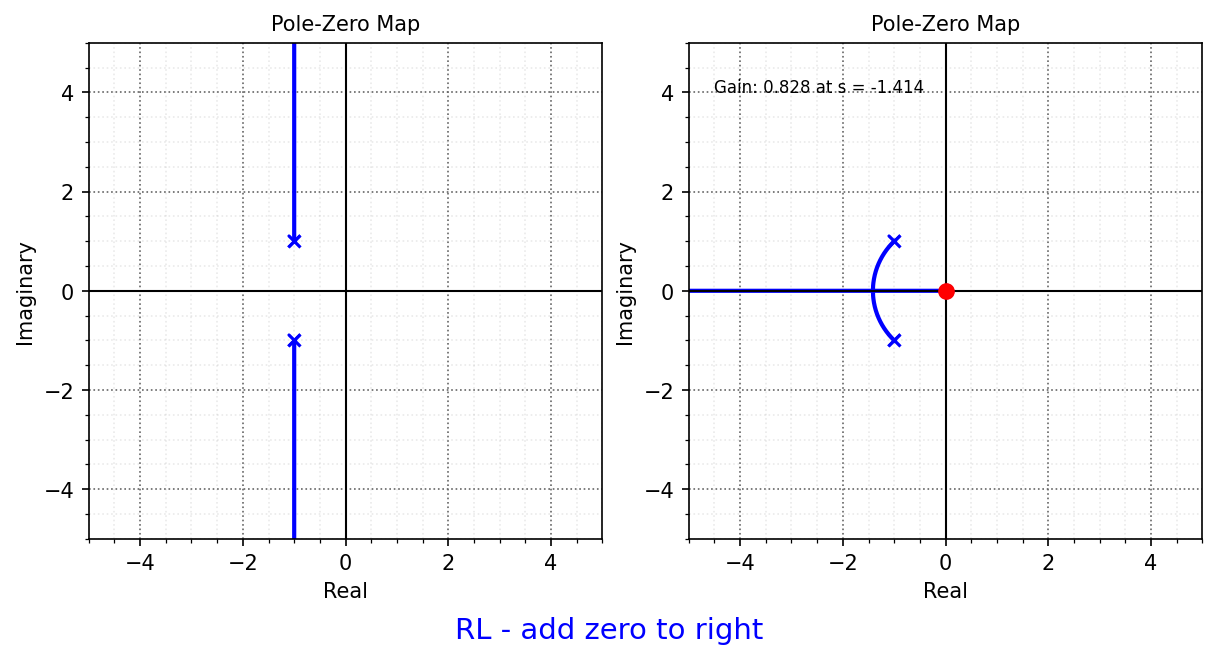

./figs/L9_2_5.pdf


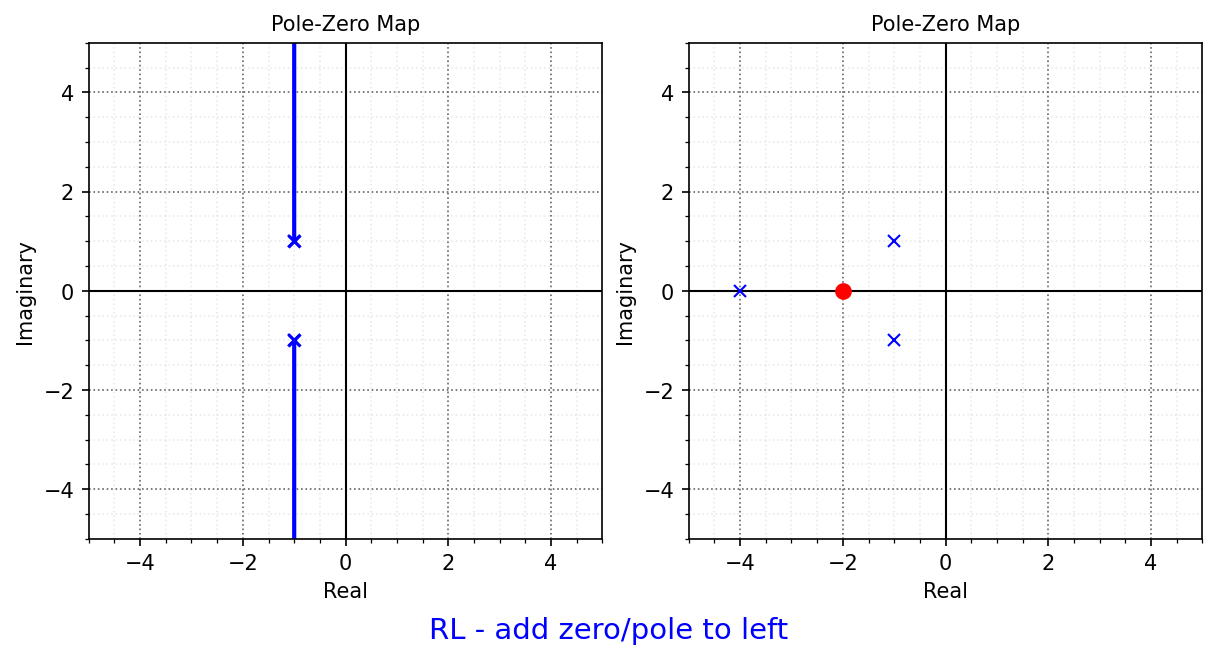

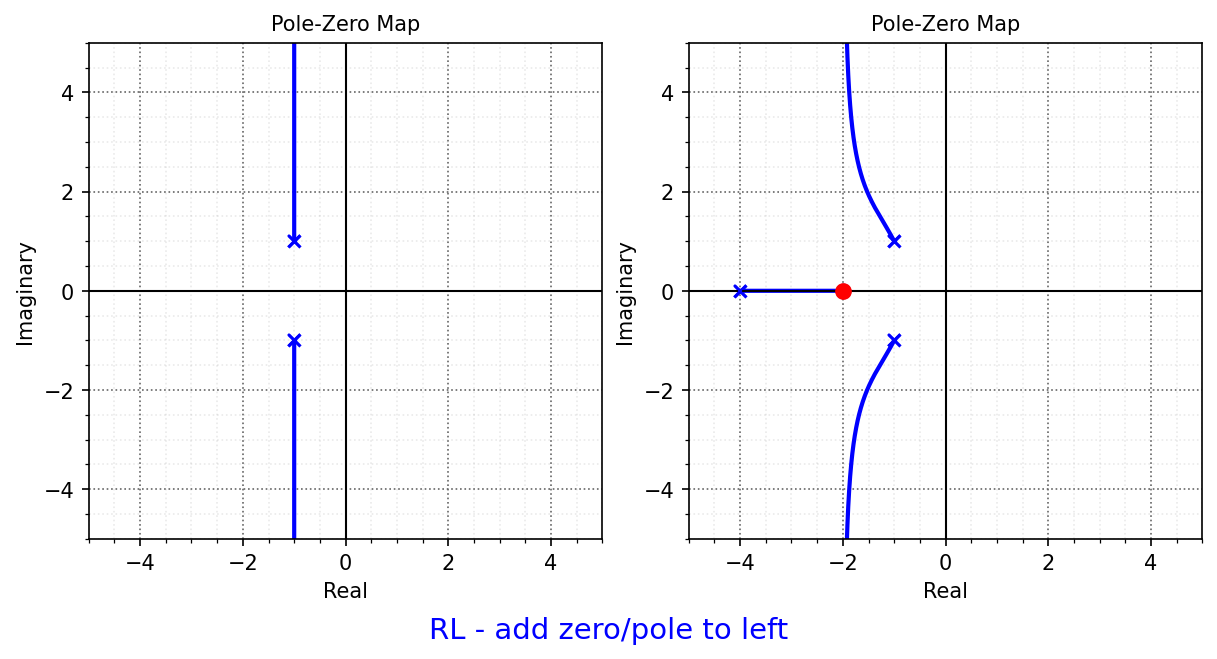

./figs/L9_2_6.pdf


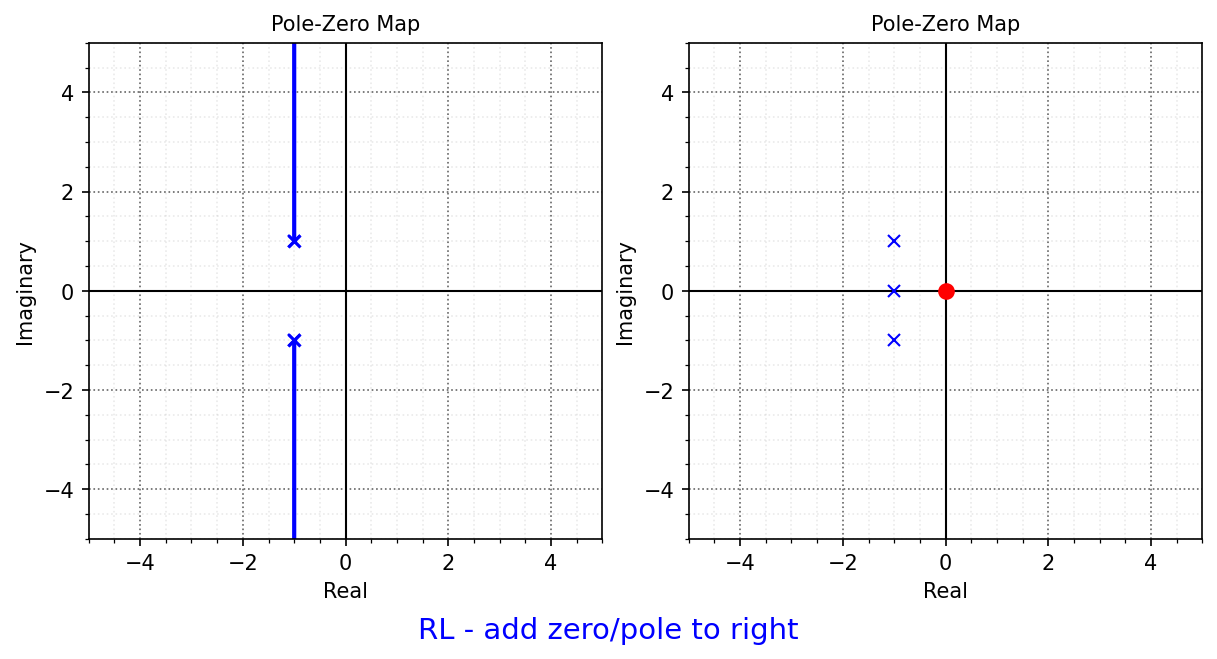

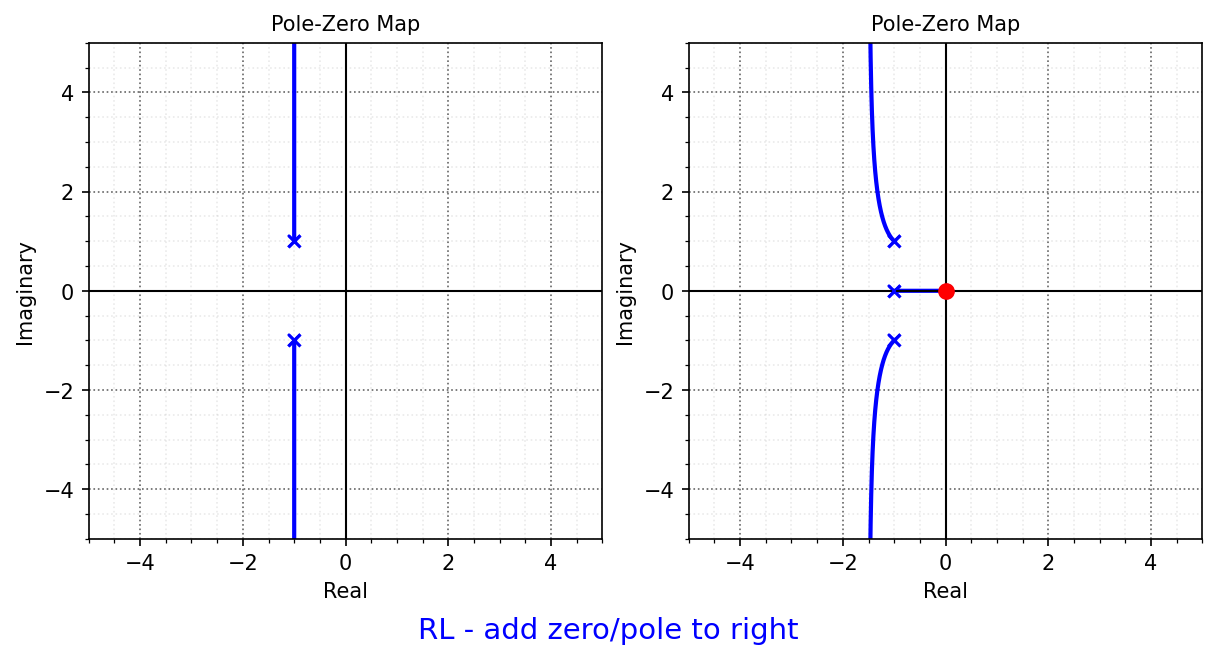

In [6]:
# add dynamics
G0 = ct.tf(1, (1,2,2))

Gd = [
    ct.tf((0, 1), (1, 2)),
    ct.tf((0, 1), (1, 0)),
    ct.tf((1, 2), (0, 1)),
    ct.tf((1, 0), (0, 1)),
    ct.tf((1, 2), (1, 4)),
    ct.tf((1, 0), (1,1))]
fig_caption = [
    "RL - add pole to left", 
    "RL - add pole to right",
    "RL - add zero to left",
    "RL - add zero to right",
    "RL - add zero/pole to left",
    "RL - add zero/pole to right"
]
file_name = "./figs/L9_2_"
plot_add_dynamics(G0,Gd,fig_caption,file_name)